<a href="https://colab.research.google.com/github/Heonyoung822/Portfolio/blob/main/GoogleColab_kNN_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 코딩으로 kNN 실습하기

In [ ]:
# Step 1. 분석할 데이터가 저장된 컴퓨터의 파일을 구글 코랩에 업로드하기
from google.colab import files
uploaded = files.upload()

Saving 수박과참외.csv to 수박과참외 (3).csv


In [ ]:
import io
import pandas as pd
src_data = pd.read_csv(io.BytesIO(uploaded['수박과참외 (3).csv']), encoding='cp949')
display(src_data.head())

,종류,무게,길이
0,수박,2000,30.0
1,수박,2500,25.0
2,수박,1800,20.0
3,수박,1500,16.0
4,수박,900,10.0


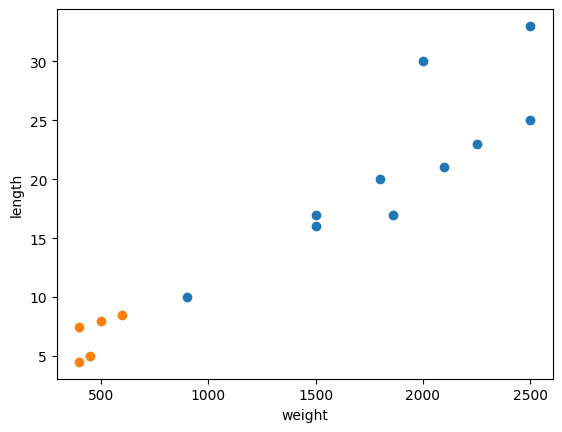

In [ ]:
# Step 2. 수박과 참외의 정보를 산점도 그래프로 출력하여 확인하기
수박정보 = src_data.loc[(src_data['종류']=='수박'), ['무게','길이']]
참외정보 = src_data.loc[(src_data['종류']=='참외'), ['무게','길이']]

import matplotlib.pyplot as plt
plt.scatter(수박정보.무게, 수박정보.길이, label='수박')
plt.scatter(참외정보.무게, 참외정보.길이, label='참외')
plt.xlabel('weight')
plt.ylabel('length')
plt.show()

In [ ]:
# Step 3. 전체 데이터를 Feature(속성값)와 Target(대상)으로 나누기
import numpy as np
# numpy의 column_stack() : 1차원 배열을 하나의 2차원 리스트(행렬)로 합치기
feature = np.column_stack((src_data.무게, src_data.길이))
target = src_data.종류
print("무게 | 길이:", '\n', feature)
print("종류:", '\n', target)

무게 | 길이: 
 [[2000.    30. ]
 [2500.    25. ]
 [1800.    20. ]
 [1500.    16. ]
 [ 900.    10. ]
 [2500.    33. ]
 [2250.    23. ]
 [1860.    17. ]
 [2100.    21. ]
 [1500.    17. ]
 [ 500.     8. ]
 [ 400.     7.5]
 [ 450.     5. ]
 [ 400.     4.5]
 [ 600.     8.5]]
종류: 
 0     수박
1     수박
2     수박
3     수박
4     수박
5     수박
6     수박
7     수박
8     수박
9     수박
10    참외
11    참외
12    참외
13    참외
14    참외
Name: 종류, dtype: object


In [ ]:
# Step 4. 주어진 데이터를 훈련용과 테스트(검증용) 세트로 나누
# sklearn의 train_test_split() --자동으로 전체 데이터를 골고루 섞은 후 훈련용과 테스트용 데이터를 분리
# 기본 설정 : 테스트용 데이터 = 전체 데이터의 25%
from sklearn.model_selection import train_test_split
train_feature, test_feature, train_target, test_target = train_test_split(
    feature, target, random_state=40
) # random_state: 실행할 때마다 결과가 달라지지 않도록 고정하는 시드값

print(train_feature.shape, test_feature.shape)

(11, 2) (4, 2)


In [ ]:
# Step 5. 학습 및 kNN 모델 생성하기
from sklearn.neighbors import KNeighborsClassifier

# n_neighbors : 가장 가까운 이웃 몇 개를 보고 판단할지 결정
kn = KNeighborsClassifier(n_neighbors=3) # 참조할 이웃의 개수를 3개로 지정
# fit()으로 train 데이터 11건을 사용해 학습 진행 후 모델 생성
kn.fit(train_feature, train_target)

# 테스트용 데이터로 모델 평가하기(분류 정확도 점수)
print(f"테스트 세트 정확도: {kn.score(test_feature, test_target)}")
# score()에 test 데이터 4건을 입력해 생성된 모델이 얼마나 정확하게 데이터를 분류하는지 테스트 -> 1.0 : 100% 정확함


테스트 세트 정확도: 1.0


In [ ]:
# Step 6. 모델이 정확한지 predict()에 임의의 데이터를 넣어 테스트하기
kn. predict([[1000, 15]]) # 무게=1000, 길이=15 -> 수박
# kn.predict() 안에 대괄호 2개 사용 : 2차원 배열값으로 값 입력 --[특정행 [값1, 값2]]

array(['수박'], dtype=object)

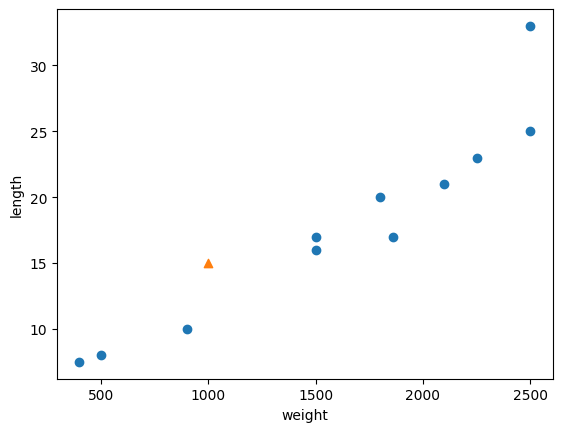

In [ ]:
# Step 7. 위 데이터 값을 산포도 그래프로 출력하여 확인하기
plt.scatter(train_feature[:,0], train_feature[:,1]) # train_feature의 모든 행의 첫 번째, 두 번째 열
# -> 무게 값과 길이 값으로 산포도 그래프 그리기
plt.scatter(1000, 15, marker='^')
plt.xlabel('weight')
plt.ylabel('length')
plt.show()

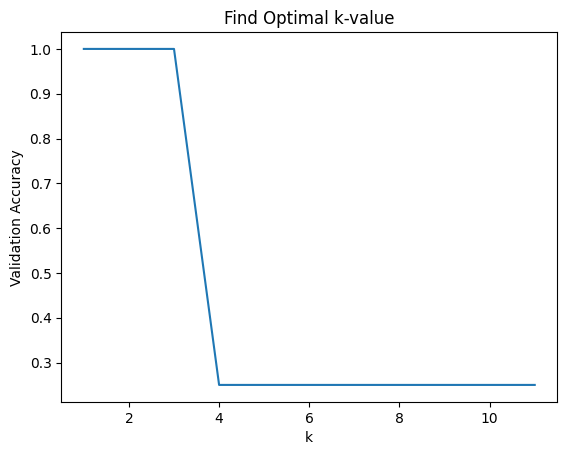

In [ ]:
# Step 8. 최적의 k 값 찾기
k_list = range(1, 12)
accuracies = []

# 1~12까지 k 값을 바꾸면서 반복적으로 실행하기
for k in k_list:
  classfier = KNeighborsClassifier(n_neighbors = k)
  # .values.ravel() : 데이터를 1차원 배열 형태로 변환
  classfier.fit(train_feature, train_target.values.ravel())
  accuracies.append(classfier.score(test_feature, test_target))

plt.plot(k_list, accuracies)
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("Find Optimal k-value")
plt.show()

In [ ]:
# Step 9. 모델의 성능 평가하기
from sklearn.metrics import confusion_matrix, accuracy_score, \
  precision_score, recall_score, f1_score
test_pred = kn.predict(test_feature)
print('1.오차혼동행렬:', '\n', confusion_matrix(test_target, test_pred))
print()
print(f'2.분류정확도(CA): {accuracy_score(test_target, test_pred):.1f}')
print(f'3.정밀도(Precision): {precision_score(test_target, test_pred, average='macro'):.1f}')
print(f'4.재현율(Recall): {recall_score(test_target, test_pred, average='macro'):.1f}')
print(f'5.F1-Score: {f1_score(test_target, test_pred, average='macro'):.1f}')

1.오차혼동행렬: 
 [[1 0]
 [0 3]]

2.분류정확도(CA): 1.0
3.정밀도(Precision): 1.0
4.재현율(Recall): 1.0
5.F1-Score: 1.0


In [ ]:
# 구글 코랩에서 생성한 모델을 저장하고 다시 불러서 사용하기
# 1. 학습된 모델 저장하기
import joblib
from google.colab import files

# 2. 모델을 훈련시키기
model = kn.fit(train_feature, train_target)

# 3. 모델을 피클 파일로 저장하기
# 피클 파일=객체 저장 파일 : 파이썬 객체(리스트, 딕셔너리, 클래스 등) 자료형을 직렬화하여 파일로 저장한 것
joblib.dump(model, "kNN_model.pkl") # 구글 드라이브에 모델 저장
files.download('kNN_model.pkl') # 코랩 환경에서 로컬로 다운로드 시 사용

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 저장된 모델을 불러서 다시 사용하기
kn2 = joblib.load("kNN_model.pkl")
kn2.predict([[800, 8]])

array(['참외'], dtype=object)